In [75]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import numpy as np
from scipy.stats import norm, probplot
from scipy import stats
import statsmodels.api as sm

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucas_60v3pre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [76]:
dados = pd.read_csv('dataset.csv')

In [77]:
print(
    f"Quantidade de notícias: {dados.shape[0]} "
    f"(fake: {dados['label'].value_counts()[0]}, "
    f"true: {dados['label'].value_counts()[1]})"
)

print(f"Quantidade de dados duplicados: {dados['text'].duplicated().sum()}")

print(f"Quantidade de dados vazios: {dados.isnull().sum().sum()}")


Quantidade de notícias: 43577 (fake: 25782, true: 17795)
Quantidade de dados duplicados: 0
Quantidade de dados vazios: 0


In [78]:
#Amostragem simples
dados.sample(10)

,id,text,label,caixa_alta,multiplas_exclamacoes,multiplas_interrogacoes,caracteres_especiais
42031,42031,A sede das Laranjeiras foi pichada na noite d...,1,0,0,0,0
11595,11595,“Caminhoneiros bloqueiam estrada e olha o que ...,0,0,0,0,0
25783,25783,STF libera prisão domiciliar a todos os detent...,0,0,0,0,0
29305,29305,"Dia 31, a partir das 8 horas da manhã, nós ire...",0,0,0,0,0
32449,32449,PS de Olivais (Lisboa) está a utilizar a vacin...,1,0,0,0,0
39222,39222,Wijnaldum abriu o placar da Holanda na golead...,1,0,0,0,0
8051,8051,curitiba tem 2 milhões de habitantes e prefeit...,0,0,0,0,0
905,905,Primeira entrevista de Alan Ruschel emociona o...,0,0,0,0,0
29380,29380,Adiamos o pagamento de dívidas dos estados e m...,0,0,0,0,0
36862,36862,A vitória do Grêmio sobre o Atlético-MG por 3 ...,1,0,0,0,1


In [79]:
dados.shape

(43577, 7)

In [80]:
dados.describe()

,id,label,caixa_alta,multiplas_exclamacoes,multiplas_interrogacoes,caracteres_especiais
count,43577.000000,43577.000000,43577.000000,43577.000000,43577.000000,43577.000000
mean,21788.000000,0.408358,0.010349,0.019024,0.005163,0.235055
std,12579.740677,0.491536,0.101206,0.136610,0.071671,0.424038
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10894.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21788.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32682.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,43576.000000,1.000000,1.000000,1.000000,1.000000,1.000000


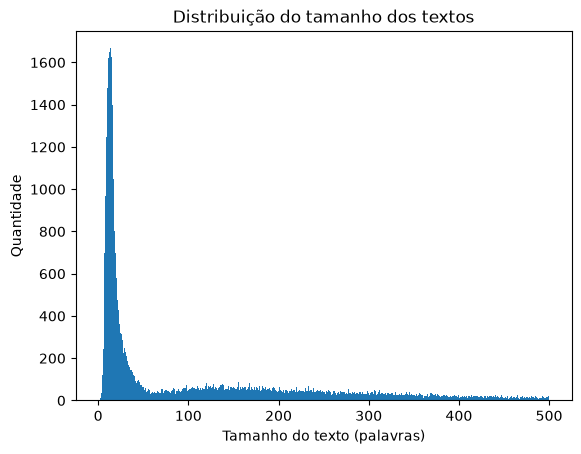

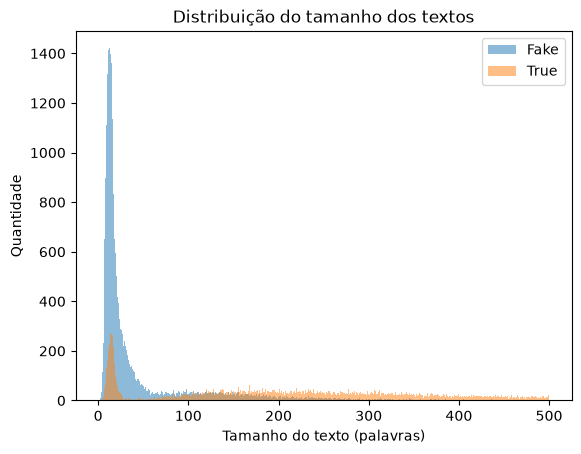

In [81]:
tamanhos = dados["text"].str.split().str.len()
plt.hist(tamanhos, bins=list(range(0, 501, 1)))
plt.xlabel("Tamanho do texto (palavras)")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos textos")
plt.show()

tamanhos_fake = tamanhos[dados["label"] == 0]
tamanhos_true = tamanhos[dados["label"] == 1]

plt.hist(
    tamanhos_fake,
    bins=list(range(0, 501, 1)),
    alpha=0.5,
    label="Fake"
)

plt.hist(
    tamanhos_true,
    bins=list(range(0, 501, 1)),
    alpha=0.5,
    label="True"
)

plt.xlabel("Tamanho do texto (palavras)")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos textos")
plt.legend()

plt.show()

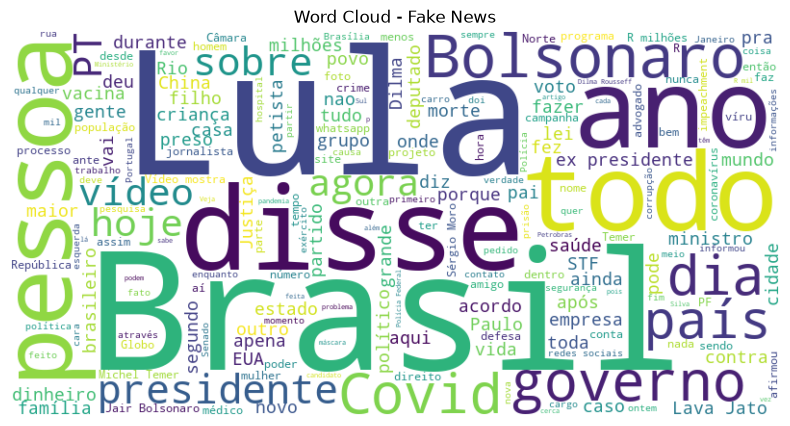

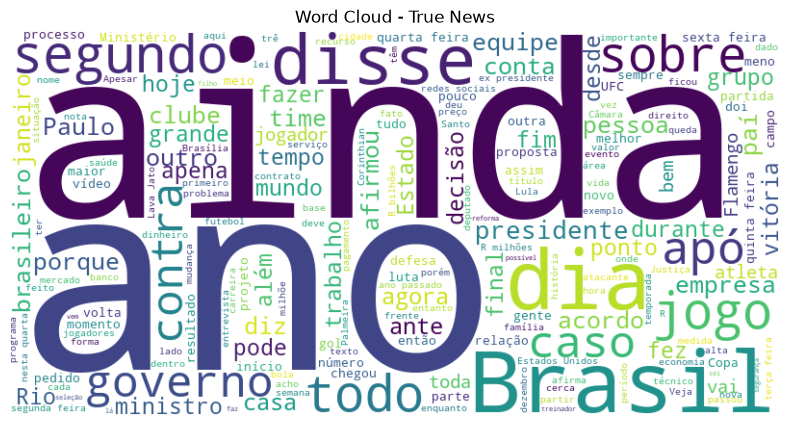

In [82]:
# Define as stopwords em português
lista_stopwords = set(stopwords.words('portuguese'))

# 1. Provide your text data
false_text = ' '.join(dados[dados['label'] == 0]['text'])
true_text = ' '.join(dados[dados['label'] == 1]['text'])

# 2. Generate the word cloud
# Custom parameters can be adjusted here (width, height, background color)
wordcloud_false = WordCloud(width=800, height=400, background_color='white', stopwords=lista_stopwords).generate(false_text)
wordcloud_true = WordCloud(width=800, height=400, background_color='white', stopwords=lista_stopwords).generate(true_text)

# 3. Display the generated image using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_false, interpolation='bilinear')
plt.title('Word Cloud - Fake News')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.title('Word Cloud - True News')
plt.axis('off')
plt.show()

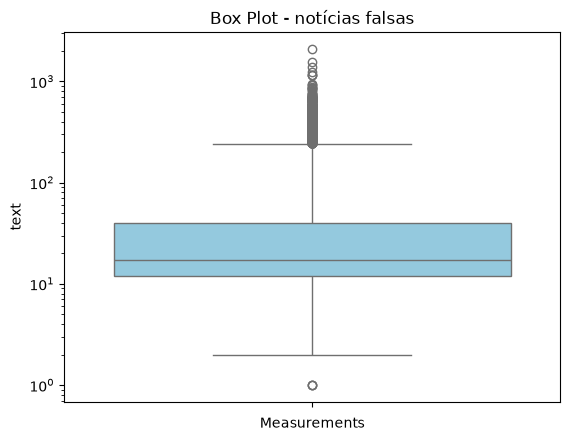

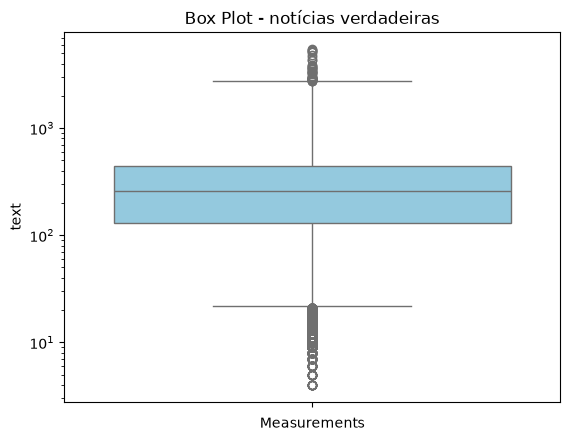

In [83]:
tamanhos_fake = dados[dados['label'] == 0]['text'].str.split().str.len()

# Create the box plot
sns.boxplot(y=tamanhos_fake, color="skyblue", log_scale=True)

plt.title("Box Plot - notícias falsas")
plt.xlabel("Measurements")
plt.show()

sns.boxplot(y=tamanhos_true, color="skyblue", log_scale=True)

plt.title("Box Plot - notícias verdadeiras")
plt.xlabel("Measurements")
plt.show()

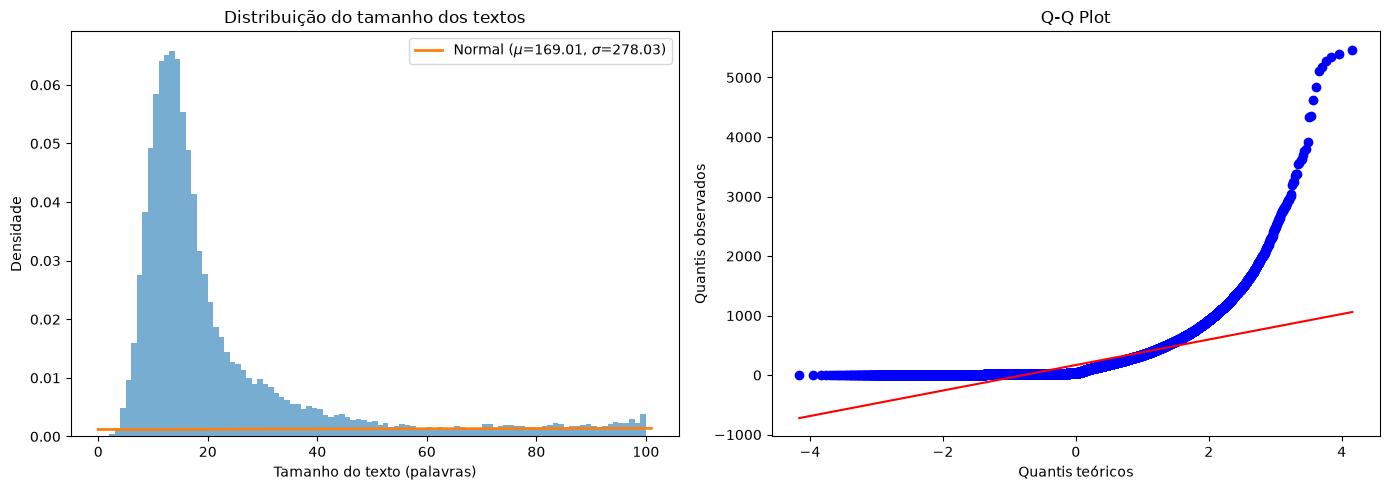

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Histograma + normal
# =========================

axes[0].hist(
    tamanhos,
    bins=list(range(0, 101, 1)),
    density=True,
    alpha=0.6
)

media = tamanhos.mean()
desvio = tamanhos.std()

x = np.linspace(0, 101, 500)
y = norm.pdf(x, media, desvio)

axes[0].plot(
    x,
    y,
    linewidth=2,
    label=f"Normal ($\\mu$={media:.2f}, $\\sigma$={desvio:.2f})"
)

axes[0].set_xlabel("Tamanho do texto (palavras)")
axes[0].set_ylabel("Densidade")
axes[0].set_title("Distribuição do tamanho dos textos")
axes[0].legend()

# =========================
# Q-Q plot
# =========================

probplot(
    tamanhos,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Q-Q Plot")
axes[1].set_xlabel("Quantis teóricos")
axes[1].set_ylabel("Quantis observados")

plt.tight_layout()
plt.show()

In [85]:
# Executando o teste de Shapiro-Wilk
estatistica, p_valor = stats.shapiro(tamanhos)

print(f"Estatística W: {estatistica}")
print(f"P-valor: {p_valor}")

# Interpretando o resultado
alpha = 0.05
if p_valor > alpha:
  print("Os dados parecem seguir uma distribuição normal (Aceita H0).")
else:
  print("Os dados não seguem uma distribuição normal (Rejeita H0).")

Estatística W: 0.5937787838307059
P-valor: 8.581453300767562e-132
Os dados não seguem uma distribuição normal (Rejeita H0).


c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43577.
  res = hypotest_fun_out(*samples, **kwds)


In [86]:
quantidade_lowercase = dados["text"].astype(str).str.islower().sum()
print(quantidade_lowercase)

3076
